In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Load metadata
df = pd.read_csv('../../input_data/whole_genome_metadata/grad_lab_complete_genomes_metadata.csv', index_col = 0)

# Get additional metadata on gender and merge with other metadata
metadata = pd.read_csv("../../input_data/lab_strains_hybrid_genomes_metadata.csv", index_col = 0)
metadata = metadata[['wgs_id', 'gender', 'has_mics', 'azithromycin', 
                     'cefixime', 'ceftriaxone', 'ciprofloxacin',
                     'gentamicin', 'penicillin', 'spectinomycin', 
                     'tetracycline', 'zoliflodacin']]
merged = df.merge(metadata, on = 'wgs_id', how = 'left')

# Get year and decade from date
merged['year'] = merged['biosample_collection_date'].str.split('-', expand = True)[0].astype('float')
merged['decade'] = merged['year'].astype('float') - (merged['year'].astype('float')%10)

# Fill NaNs with NA for continent and gender
merged[['continent', 'gender']] = merged[['continent', 'gender']].fillna(value='NA')
merged['Source'] = 'Sequenced in this study'

In [47]:
# Load metadata for public genomes
metadata_public = pd.read_csv('../../input_data/whole_genome_metadata/public_complete_genomes_metadata.csv')
metadata_public['continent'] = metadata_public['continent'].fillna(value='NA')

# Get year and decade from date
metadata_public['year'] = metadata_public['biosample_collection_date'].str.split('-', expand = True)[0].astype('float')
metadata_public['decade'] = metadata_public['year'].astype('float') - (metadata_public['year'].astype('float')%10)

metadata_public['Source'] = 'Publicly available'

In [29]:
# Combine continent metadata for all genomes
continent = pd.concat([merged[['wgs_id', 'continent', 'Source']], metadata_public[['wgs_id', 'continent', 'Source']]])
continent.reset_index(inplace = True, drop = True)

# Make North America and South America labels appear on 2 lines for space reasons
continent.replace(to_replace='North America', value='North\nAmerica', inplace=True)
continent.replace(to_replace='South America', value='South\nAmerica', inplace=True)

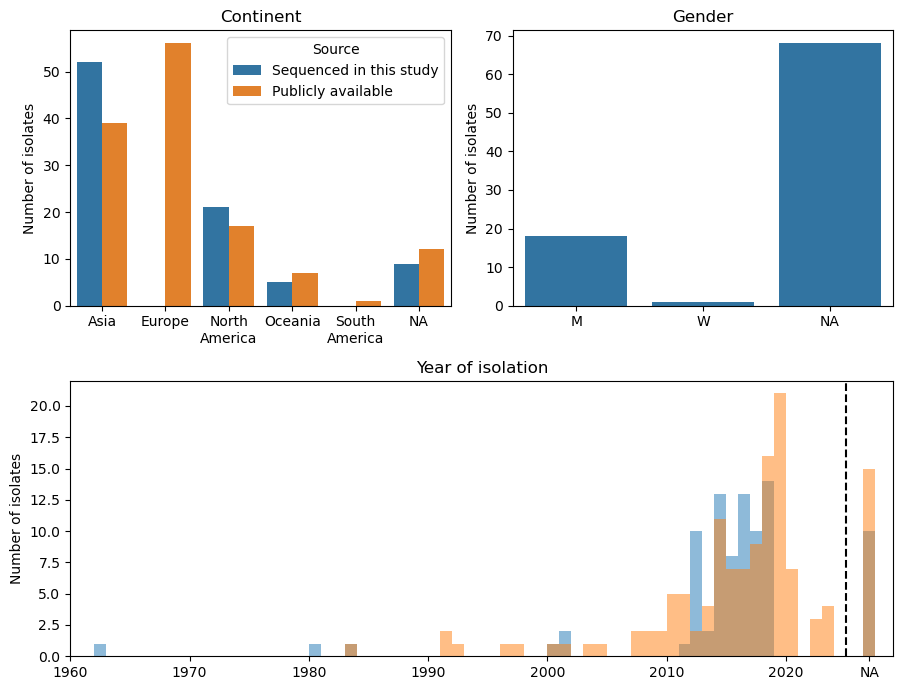

In [67]:
# Set up subplots: 2 on top and 1 on bottom
fig, ax = plt.subplots(2,2,figsize = (9,7))#3, width_ratios = [1, 1, 3])

for a in ax[1, :]:
    a.remove()

gs = ax[0, 0].get_gridspec()
ax3 = fig.add_subplot(gs[1, :])   # second row, all columns

# PLOT CONTINENTS

# Get order of values for plot
values = np.unique(continent['continent'])
# Mask of non-NaN values
mask = values!='NA'
# New array with NaNs moved to the end
order = np.concatenate([values[mask], values[~mask]])

sns.countplot(continent, x = 'continent', hue = 'Source', order = order, ax = ax[0,0])#,color = 'tab:blue')

ax[0,0].set_xlabel('')
ax[0,0].set_title('Continent')
ax[0,0].set_ylabel('Number of isolates')

# PLOT GENDERS

# Get order of values for plot
values = np.unique(merged['gender'])
# Mask of non-NaN values
mask = values!='NA'
# New array with NaNs moved to the end
order = np.concatenate([values[mask], values[~mask]])

sns.countplot(merged, x = 'gender', order = order, color = 'tab:blue', ax = ax[0,1])

ax[0,1].set_xlabel('')
ax[0,1].set_title('Gender')
ax[0,1].set_ylabel('Number of isolates')

# PLOT YEARS

### For Grad lab sequenced genomes

# Get an array of the years as floats
year_float = merged['year'].values
# Number of years with "NA"
num_year_na = np.isnan(year_float).sum()

# Plot valid years
n, bins, patches = ax3.hist(year_float, np.arange(np.nanmin(year_float), np.nanmax(year_float)+1), alpha = 0.5)

# Place the NA bar
bin_width = bins[1] - bins[0]
x_nan_center = 2027 # x position of the NaN bar center
ax3.bar(x_nan_center, num_year_na, width=bin_width, color = 'tab:blue', alpha = 0.5)

### For public genomes

# Get an array of the years as floats
year_float_public = metadata_public['year'].values
# Number of years with "NA"
num_year_na_public = np.isnan(year_float_public).sum()

# Plot valid years
n_public, bins_public, patches_public = ax3.hist(year_float_public, np.arange(np.nanmin(year_float_public), np.nanmax(year_float_public)+1), alpha = 0.5)

# Place the NA bar
bin_width_public = bins_public[1] - bins_public[0]
x_nan_center_public = 2027 # x position of the NaN bar center
ax3.bar(x_nan_center_public, num_year_na_public, width=bin_width_public, color = 'tab:orange', alpha = 0.5)

# Put a tick label for the NaN bar
ax3.set_xticks(list(ax3.get_xticks()) + [x_nan_center_public])
ax3.set_xticklabels(
    [lab for lab in ax3.get_xticks().astype('int')[:-1]] + ['NA'],  # simple relabel; adjust as needed
    rotation=0
)

# Add divider for NA bar for visual clarity
ax3.plot([2025, 2025], [0, 22], 'k--')

ax3.set_xlim([1960, 2029])
ax3.set_ylim([0, 22])
ax3.set_ylabel("Number of isolates")
ax3.set_title("Year of isolation")

plt.tight_layout()

plt.savefig('../../figures/assembly_summary/complete_genomes_metadata.png', dpi = 300)
plt.savefig('../../figures/assembly_summary/complete_genomes_metadata.pdf')

plt.show()